# 01 — Data Loading & Data Understanding

This section covers the initial foundation of the project: importing the required libraries, loading the dataset, validating its structure, and performing basic exploratory data analysis (EDA). These steps establish a baseline understanding of the data and ensure that the dataset is clean, interpretable, and ready for later stages such as feature exploration, risk segmentation, modeling, and insight generation.

## 1. Data Loading

We begin by importing the dataset from the project's `data/` directory and displaying the first few rows to confirm that the data has loaded correctly.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Dataset Structure

We inspect the dataset's structure, column types, and overall shape. This helps us understand what kinds of variables we are working with and whether any preprocessing may be required.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


## 3. Descriptive Statistics

Summary statistics provide an overview of the numerical features, including central tendencies, variability, and potential outliers. This is a key part of understanding the dataset's numerical structure.

In [3]:
df.describe

<bound method NDFrame.describe of        person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_a

## 4. Missing Values

We check for missing values to assess data quality and identify potential preprocessing needs before deeper analysis.

In [4]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## 5. Distribution Analysis

We analyze the distribution of a key numeric variable. Loan amount is a central risk-related feature, making it a suitable candidate for initial distribution analysis.

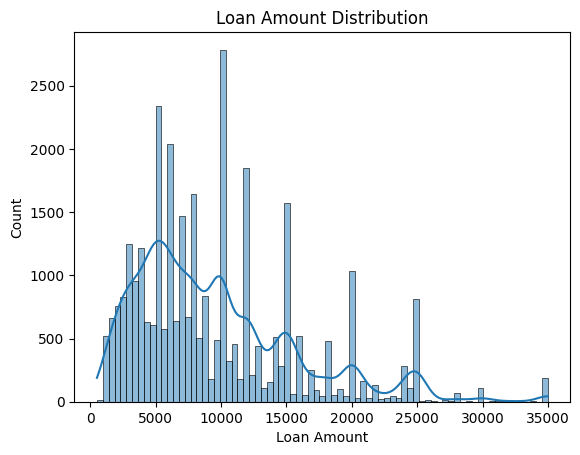

In [5]:
sns.histplot(df["loan_amnt"], kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

## 6. Segment Analysis (Boxplot)

This boxplot compares income levels between the two loan status groups (x-axis: 0 = no default, 1 = default). The y-axis shows the income values.

The income variable contains extremely large outliers (up to ~6,000,000), which makes the boxplot unreadable on a normal linear scale because almost all values are compressed near the bottom. To fix this, the y-axis is shown using a logarithmic scale. Log-scaling spreads the values more evenly and makes the differences between the two segments visible without removing any data.

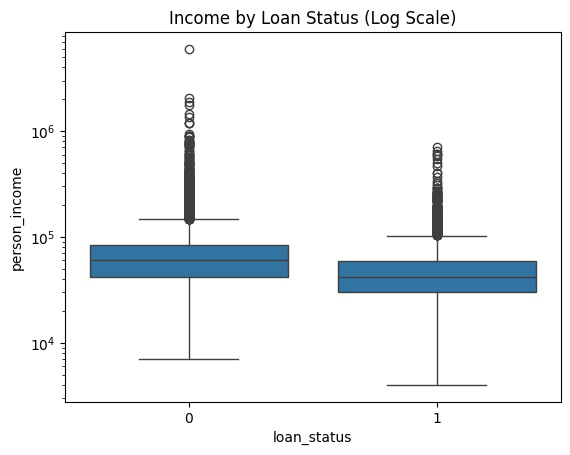

In [8]:
sns.boxplot(data=df, x="loan_status", y="person_income")
plt.yscale("log")
plt.title("Income by Loan Status (Log Scale)")
plt.show()

## 7. Correlation Analysis

We compute correlations only for numeric columns to avoid errors caused by categorical values. This heatmap reveals relationships between key risk-related variables such as income, loan amount, interest rate, employment length, and credit history length.

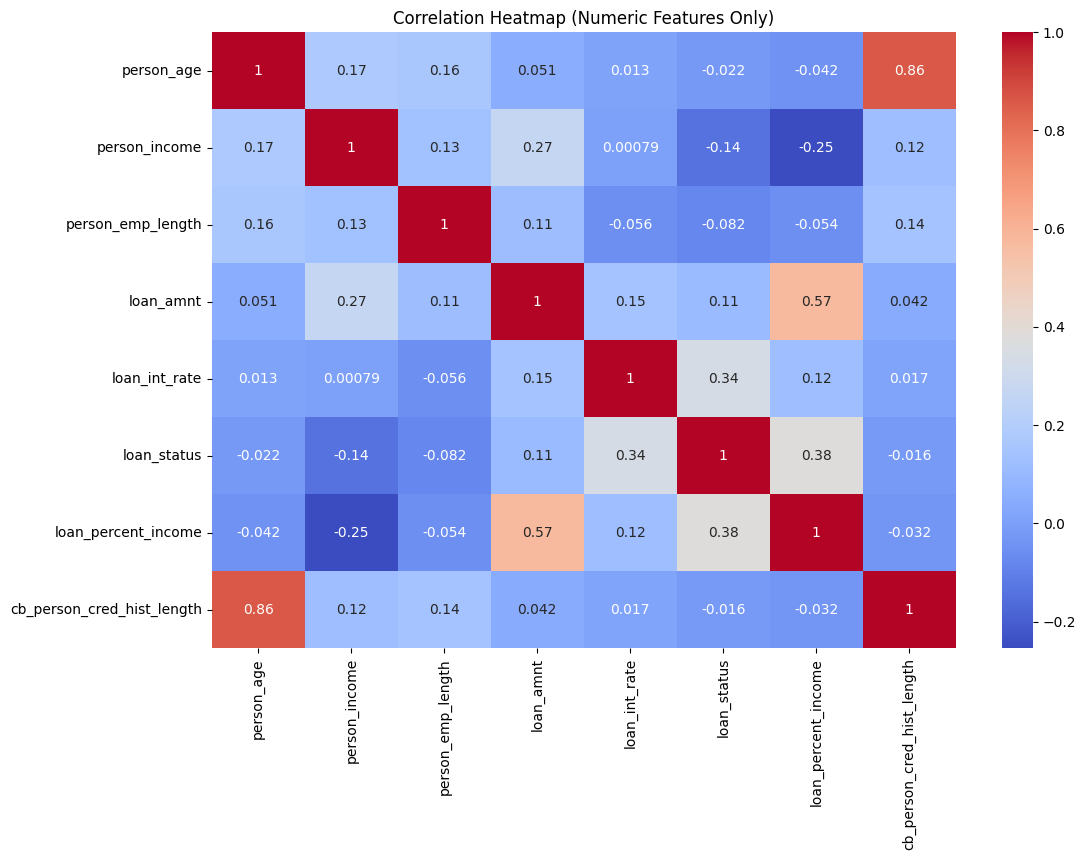

In [7]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()